# PCA Reconstruction Baseline

This notebook uses PCA reconstruction error as a linear baseline for ECG anomaly detection.

The idea is simple: PCA is fitted on normal beats, then each beat is reconstructed from a lower-dimensional representation. Beats with high reconstruction error are treated as anomalies.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import PCAReconstructionAnomalyDetector

## Load Records

In [2]:
N_RECORDS = 5

records_file = Path(config.MIT_BIH_PATH) / "RECORDS"
record_names = records_file.read_text().splitlines()[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

Loaded 5 records: ['100', '101', '102', '103', '104']


## Create Beat Dataset

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10634, 7)


,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     6440
anomaly    4194
Name: count, dtype: int64

symbol
N    6440
/    3407
f     722
A      38
Q      20
V       7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values)
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10634, 180)
y shape: (10634,)


## Train/Test Split by Record

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '102', '103']
Test records: ['104']
Train shape: (8406, 180)
Test shape: (2228, 180)
Train labels:


normal     6277
anomaly    2129
Name: count, dtype: int64

Test labels:


anomaly    2065
normal      163
Name: count, dtype: int64

## Fit PCA Reconstruction Model

PCA is fitted only on normal training beats. This follows a semi-supervised anomaly detection setup: the model learns the structure of normal beats and flags high reconstruction errors as anomalies.

In [6]:
N_COMPONENTS = 8

X_train_normal = split["X_train"][split["y_train"] == 0]

pca_model = PCAReconstructionAnomalyDetector(
    n_components=N_COMPONENTS,
    threshold_percentile=95,
    random_state=config.RANDOM_SEED,
)
pca_model.fit(X_train_normal)

MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_eval = split["X_test"][test_indices]
y_test_eval = split["y_test"][test_indices]

print("Normal training beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_eval))
display(pd.Series(y_test_eval).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("PCA components:", N_COMPONENTS)
print("Threshold:", pca_model.threshold)

Normal training beats used: 6277
Test beats used: 300


normal     150
anomaly    150
Name: count, dtype: int64

PCA components: 8
Threshold: 0.0002254877363127261


## Evaluate

In [7]:
scores = pca_model.anomaly_score(X_test_eval)
y_pred = pca_model.predict(X_test_eval)

results = evaluate_anomaly_detection(y_test_eval, y_pred, scores)
results

{'confusion_matrix': [[0, 150], [0, 150]],
 'precision': 0.5,
 'recall': 1.0,
 'f1': 0.6666666666666666,
 'roc_auc': 0.93,
 'pr_auc': 0.9601879097989057}

### Metric Interpretation

With the default 95th percentile threshold, PCA classifies all evaluated beats as anomalies. On the balanced evaluation subset this gives perfect recall, but precision is only 0.5 because all normal beats become false positives.

The ROC-AUC and PR-AUC remain high, which means the reconstruction error still contains useful ranking information. The main issue is not the score itself, but the operating threshold used to convert scores into binary predictions.

## Threshold Sensitivity

In [8]:
threshold_results = []
train_scores = pca_model.anomaly_score(X_train_normal)

for percentile in [95, 97, 98, 99, 99.5, 99.9]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_eval, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95.0,0.000225,0.500000,1.00,0.666667,0.93,0.960188
1,97.0,0.000289,0.500000,1.00,0.666667,0.93,0.960188
2,98.0,0.000348,0.500000,1.00,0.666667,0.93,0.960188
3,99.0,0.000521,0.500000,1.00,0.666667,0.93,0.960188
4,99.5,0.000946,0.500000,1.00,0.666667,0.93,0.960188
5,99.9,0.002158,0.704082,0.92,0.797688,0.93,0.960188


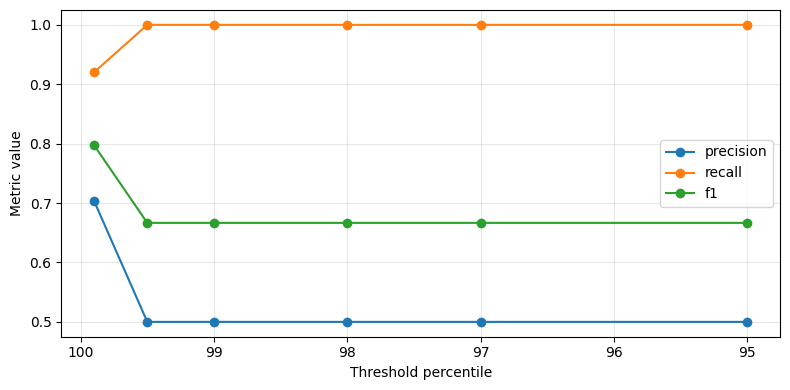

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

Unlike ARMA, PCA needs a much higher threshold percentile in this preliminary experiment. At the 99.9th percentile, the model stops predicting every beat as anomalous and reaches a better precision/recall trade-off.

This suggests that normal beats from the test record can have larger reconstruction errors than normal beats from the training records. In other words, PCA is sensitive to record-level or patient-level differences, which is an important limitation to discuss.

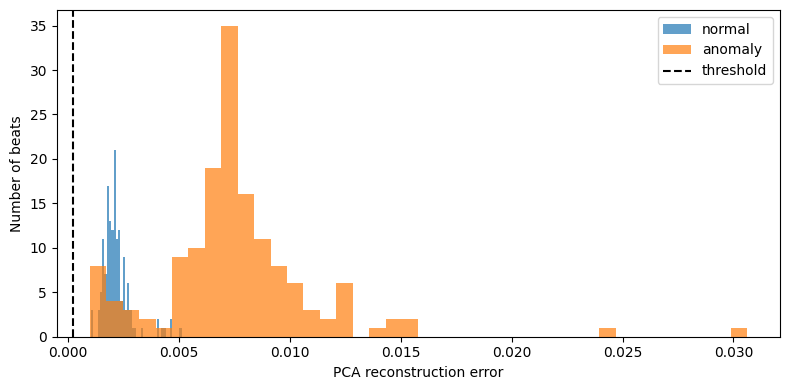

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_eval == 0], bins=40, alpha=0.7, label="normal")
plt.hist(scores[y_test_eval == 1], bins=40, alpha=0.7, label="anomaly")
plt.axvline(pca_model.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("PCA reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Preliminary Comparison with ARMA

Both ARMA and PCA were evaluated on the same five-record setup and on a balanced subset of the test record. These results are preliminary and should be interpreted as a pipeline check, not as final model performance.

| Model | Operating point | Precision | Recall | F1 | ROC-AUC | PR-AUC | Main observation |
|---|---:|---:|---:|---:|---:|---:|---|
| ARMA | 95th percentile | 0.914 | 0.213 | 0.346 | 0.955 | 0.941 | Conservative: few anomalies detected, but predictions are reliable. |
| PCA | 95th percentile | 0.500 | 1.000 | 0.667 | 0.930 | 0.960 | Too sensitive: predicts every evaluated beat as anomalous. |
| PCA | 99.9th percentile | 0.704 | 0.920 | 0.798 | 0.930 | 0.960 | Better threshold for this subset; high recall with moderate precision. |

The comparison shows that the threshold choice can change the practical behavior of a detector as much as the model itself. ARMA is conservative with the default threshold, while PCA is overly sensitive unless a much higher percentile is used.

## Interpretation Notes

- PCA is a linear reconstruction baseline.
- It can be interpreted as a simple linear autoencoder.
- This makes it a useful bridge between classical methods and neural autoencoders.
- In this preliminary experiment, the default 95th percentile threshold is too low for the test record and classifies all evaluated beats as anomalies.
- This suggests a distribution shift between training records and the test record: even normal beats from the test record can have higher reconstruction error than normal beats from training records.
- Higher threshold percentiles should therefore be inspected before choosing an operating point.
- If PCA performs poorly, it suggests that linear structure is not enough to model ECG beat morphology.
- If PCA performs reasonably well, later deep models must justify their extra complexity.